<a href="https://colab.research.google.com/github/Ebrar6565/smart-city-satellite-analysis/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Akıllı Şehir Planlama: Uydu Görüntüleri ile Kentsel Analiz

## Projenin Amacı

Bu projede uydu görüntüleri üzerinde semantic segmentation teknikleri kullanılarak bina, yol, su, bitki örtüsü ve farklı arazi türlerinin piksel düzeyinde sınıflandırılması amaçlanmaktadır.

Model çıktılarından:

- Yapılaşma oranı
- Yol oranı
- Bitki örtüsü oranı
- Bölgesel yapı yoğunluğu

gibi kentsel analiz göstergeleri üretilecektir.

## İlk Aşama

Bu notebook içerisinde veri setindeki uydu görüntüleri ve bunlara karşılık gelen segmentation maskeleri incelenecektir.

In [ ]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

print("Python sürümü:")
print(sys.version)

print("\nKütüphaneler başarıyla yüklendi.")

Python sürümü:
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Kütüphaneler başarıyla yüklendi.


## Semantic Segmentation Maskesinin Yapısı

Semantic segmentation işleminde görüntüdeki her piksele bir sınıf numarası atanır.

Bu örnekte:

- 0: Arka plan
- 1: Bina
- 2: Yol
- 3: Su
- 4: Bitki örtüsü

olarak temsil edilmektedir.

Maskenin boyutu: (8, 8)
Maskede bulunan sınıf numaraları: [0 1 2 3 4]

Sayısal maske:
[[4 4 4 0 0 1 1 1]
 [4 4 4 0 0 1 1 1]
 [4 4 4 2 2 1 1 1]
 [0 0 0 2 2 0 0 0]
 [0 3 3 2 2 0 1 1]
 [0 3 3 2 2 0 1 1]
 [4 4 0 2 2 0 1 1]
 [4 4 0 2 2 0 0 0]]


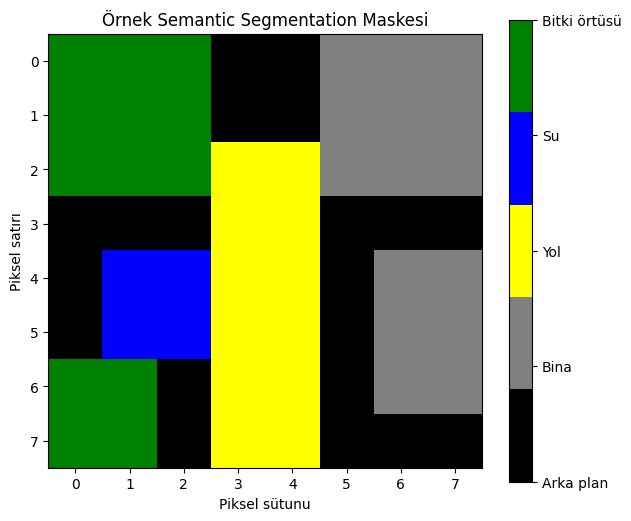

In [2]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
# Sınıf isimleri
class_names = {
    0: "Arka plan",
    1: "Bina",
    2: "Yol",
    3: "Su",
    4: "Bitki örtüsü"
}

# Küçük bir örnek segmentation maskesi
mask = np.array([
    [4, 4, 4, 0, 0, 1, 1, 1],
    [4, 4, 4, 0, 0, 1, 1, 1],
    [4, 4, 4, 2, 2, 1, 1, 1],
    [0, 0, 0, 2, 2, 0, 0, 0],
    [0, 3, 3, 2, 2, 0, 1, 1],
    [0, 3, 3, 2, 2, 0, 1, 1],
    [4, 4, 0, 2, 2, 0, 1, 1],
    [4, 4, 0, 2, 2, 0, 0, 0]
])

print("Maskenin boyutu:", mask.shape)
print("Maskede bulunan sınıf numaraları:", np.unique(mask))
print("\nSayısal maske:")
print(mask)

# Maskeyi renkli olarak gösterme
colors = ["black", "gray", "yellow", "blue", "green"]
cmap = ListedColormap(colors)

plt.figure(figsize=(7, 6))

image = plt.imshow(
    mask,
    cmap=cmap,
    vmin=0,
    vmax=len(class_names) - 1
)

colorbar = plt.colorbar(
    image,
    ticks=list(class_names.keys())
)

colorbar.ax.set_yticklabels(class_names.values())

plt.title("Örnek Semantic Segmentation Maskesi")
plt.xlabel("Piksel sütunu")
plt.ylabel("Piksel satırı")
plt.show()

In [3]:
# Maskedeki toplam piksel sayısı
total_pixels = mask.size

# Her sınıfın piksel sayısını bulma
class_ids, pixel_counts = np.unique(mask, return_counts=True)

print("Toplam piksel sayısı:", total_pixels)
print("-" * 45)

for class_id, pixel_count in zip(class_ids, pixel_counts):
    class_name = class_names[class_id]
    percentage = (pixel_count / total_pixels) * 100

    print(
        f"{class_name:<15}: "
        f"{pixel_count:>2} piksel - "
        f"%{percentage:.2f}"
    )

Toplam piksel sayısı: 64
---------------------------------------------
Arka plan      : 20 piksel - %31.25
Bina           : 15 piksel - %23.44
Yol            : 12 piksel - %18.75
Su             :  4 piksel - %6.25
Bitki örtüsü   : 13 piksel - %20.31


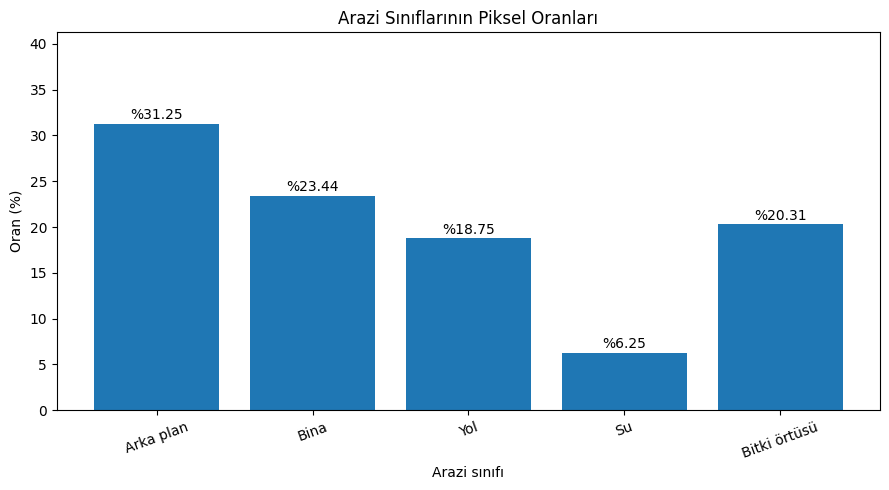

In [4]:
analysis_names = []
analysis_percentages = []

for class_id, pixel_count in zip(class_ids, pixel_counts):
    analysis_names.append(class_names[class_id])
    analysis_percentages.append(
        (pixel_count / total_pixels) * 100
    )

plt.figure(figsize=(9, 5))

bars = plt.bar(
    analysis_names,
    analysis_percentages
)

plt.title("Arazi Sınıflarının Piksel Oranları")
plt.xlabel("Arazi sınıfı")
plt.ylabel("Oran (%)")
plt.ylim(0, max(analysis_percentages) + 10)

for bar, percentage in zip(bars, analysis_percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"%{percentage:.2f}",
        ha="center"
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()